# Car Price Prediction using Supervised Machine Learning

## Objective
The objective of this project is to build regression models that predict the selling price of a car based on various features such as year, fuel type, transmission, and kilometers driven.

## Algorithms Used
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("/content/car_prediction_data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [4]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Check Missing Values

## Handling Missing Values
Missing values can affect model performance. We check if the dataset contains any null values.

In [5]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


Remove Duplicates

## Removing Duplicate Records
Duplicate records were removed to ensure that the dataset does not contain repeated observations.

In [6]:
df.drop_duplicates(inplace=True)

Check Data Types

## Fixing Data Types
We verify that all columns have appropriate data types for machine learning.

In [7]:
df.dtypes

,0
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Kms_Driven,int64
Fuel_Type,object
Seller_Type,object
Transmission,object
Owner,int64


Detect Outliers

## Detecting Outliers
Outliers can negatively impact model performance. Boxplots are used to detect extreme values.

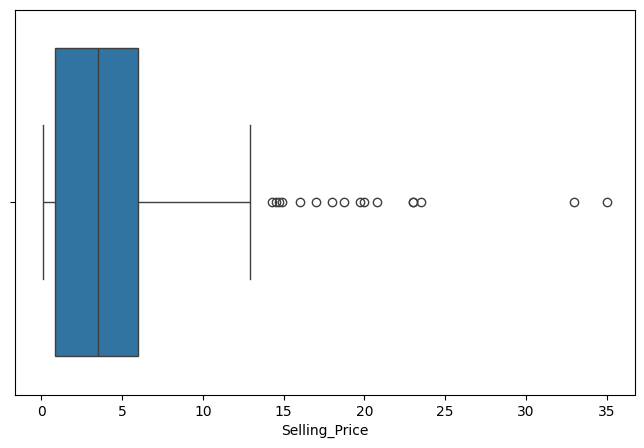

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Selling_Price'])
plt.show()

Encode Categorical Variables

## Handling Categorical Variables
Machine learning models require numerical input. Therefore, categorical variables such as fuel type, transmission, and seller type are encoded.

In [9]:
le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Seller_Type'] = le.fit_transform(df['Seller_Type'])
df['Transmission'] = le.fit_transform(df['Transmission'])

Remove Irrelevant Features

In [10]:
df = df.drop(['Car_Name'], axis=1)

Feature Scaling

## Feature Scaling
Feature scaling ensures that all variables contribute equally to the model by bringing them to a similar scale.

In [11]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train Test Split

## Splitting Dataset
The dataset is split into training and testing sets to evaluate model performance.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Linear Regression

## Linear Regression Model
Linear Regression is a basic regression algorithm that models the relationship between independent variables and the target variable.

In [13]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## Decision Tree Regressor
Decision Tree creates a tree structure to predict numerical values based on feature splits.

In [14]:
dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

## Random Forest Regressor
Random Forest is an ensemble model that combines multiple decision trees to improve prediction accuracy.

In [15]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Model Evaluation

In [16]:
def evaluate_model(y_test, y_pred):

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    return r2, mse, rmse, mae

Calculate Metrics

In [18]:
lr_metrics = evaluate_model(y_test, y_pred_lr)
dt_metrics = evaluate_model(y_test, y_pred_dt)
rf_metrics = evaluate_model(y_test, y_pred_rf)

print("Linear Regression:", lr_metrics)
print("Decision Tree:", dt_metrics)
print("Random Forest:", rf_metrics)

Linear Regression: (0.7410829335731295, 6.673137446828262, np.float64(2.5832416547485955), 1.5410718122837634)
Decision Tree: (0.7902436012929162, 5.406106666666667, np.float64(2.3251035819220327), 1.1183333333333332)
Random Forest: (0.5151984717107339, 12.494916914333341, np.float64(3.534814975968805), 1.512016666666668)


Model Comparison Table

In [19]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2 Score": [lr_metrics[0], dt_metrics[0], rf_metrics[0]],
    "MSE": [lr_metrics[1], dt_metrics[1], rf_metrics[1]],
    "RMSE": [lr_metrics[2], dt_metrics[2], rf_metrics[2]],
    "MAE": [lr_metrics[3], dt_metrics[3], rf_metrics[3]]
})

results

,Model,R2 Score,MSE,RMSE,MAE
0,Linear Regression,0.741083,6.673137,2.583242,1.541072
1,Decision Tree,0.790244,5.406107,2.325104,1.118333
2,Random Forest,0.515198,12.494917,3.534815,1.512017


## Conclusion

Three regression models were trained to predict car selling prices.

Random Forest achieved the best performance with the highest R² score and lowest error values, indicating better predictive capability compared to Linear Regression and Decision Tree.

This project demonstrates the importance of proper data preprocessing and model evaluation in supervised machine learning.